In [1]:
import warnings

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

from tensorflow import keras
from keras import optimizers, initializers

from tensorflow.keras.callbacks import Callback
from tqdm.keras import TqdmCallback
from tqdm import tqdm

from scipy.stats import norm

import thetaflow as thf

2026-03-11 04:10:08.933172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773213008.950755  202036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773213008.955927  202036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773213008.970548  202036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773213008.970570  202036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773213008.970572  202036 computation_placer.cc:177] computation placer alr

# General framework

Let us consider that for a given statistical model, we can segment the vector of parameters, $\boldsymbol \theta$ into two major sets of parameters:
* $\boldsymbol{\phi}$: Parameters that can be modeled as outputs to a neural network;
* $\boldsymbol{\psi}$: Global parameters modeled as constants for the entire population;

# Linear regression variations

### $\phi = \emptyset, \psi = \{\mu, \sigma^2\}$

Sample mean: 5.0794166629368735
Sample variance: 0.9446114649458076


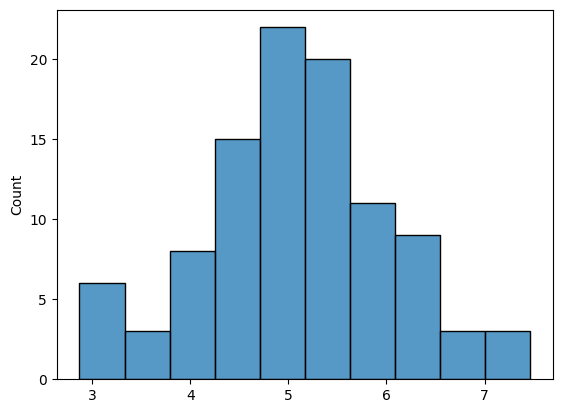

In [2]:
n = 100

mu_0 = 5
sigma2_0 = 1

np.random.seed(10)

y0 = np.random.normal(loc = mu_0, scale = np.sqrt(sigma2_0), size = n)

print("Sample mean: {}".format(np.mean(y0)))
print("Sample variance: {}".format(np.var(y0, ddof = 1)))

sns.histplot(x = y0)
plt.show()

In [3]:
regression0_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y0)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y0)}
}

def regression0_loglikelihood_loss(model, nn_output, data):
    X, y = data

    mu = model.get_variable("mu")
    sigma2 = model.get_variable("sigma2")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    
    return -loglik

In [4]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression0_model = thf.ModelNN(regression0_parameters, regression0_loglikelihood_loss,
                                    None, None, None,
                                    input_dim = (None, 1), seed = 10)
    
    data0 = [y0]
    
    regression0_mu_before_pretrain = regression0_model.predict("mu")
    regression0_sigma2_before_pretrain = regression0_model.predict("sigma2")
    
    regression0_model.train_model(None, data0,
                                  epochs = 5000, shuffle = True,
                                  metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                  deterministic = True,
                                  verbose = 1)
    
    regression0_mu_after_train = regression0_model.predict("mu")
    regression0_sigma2_after_train = regression0_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 200 / 5000 ]  | Loss:  0 | Param Dist:  0.000121033496 | Independent Learning rate:  0.01 | Network Learning rate:  0.01 | Speed:  4354  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 4.437 seconds.


In [5]:
df_summary0 = regression0_model.summary()
df_summary0

,index,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,5.084392,0.096467,4.89532,5.273463,0.930538,0.131274,0.673246,1.187829


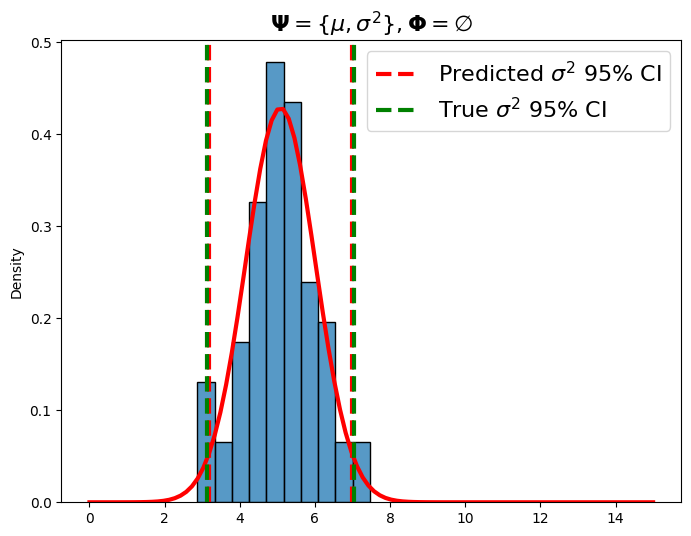

In [6]:
xs = np.linspace(0, 15, 100)

alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var0 = df_summary0["mu_se"]**2 + df_summary0["sigma2"]
y_new_lower0 = df_summary0["mu"] - z_norm * np.sqrt(y_new_var0)
y_new_upper0 = df_summary0["mu"] + z_norm * np.sqrt(y_new_var0)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = y0, stat = "density", ax = ax)
sns.lineplot(x = xs, y = norm.pdf(xs, loc = regression0_mu_after_train, scale = regression0_sigma2_after_train), color = "red", linewidth = 3, ax = ax)
ax.axvline(y_new_lower0[0], color = "red", linewidth = 3, linestyle = "dashed", label = r"Predicted $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0[0], color = "red", linewidth = 3, linestyle = "dashed")

sort_sigma2_0 = sigma2_0
y_new_lower0_true = df_summary0["mu"] - z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )
y_new_upper0_true = df_summary0["mu"] + z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )

ax.axvline(y_new_lower0_true[0], color = "green", linewidth = 3, linestyle = "dashed", label = r"True $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0_true[0], color = "green", linewidth = 3, linestyle = "dashed")
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu, \sigma^2\}, \boldsymbol{\Phi} = \emptyset$", fontsize = 16)

plt.show()

### $\phi = \{\mu\}, \psi = \{\sigma^2\}$

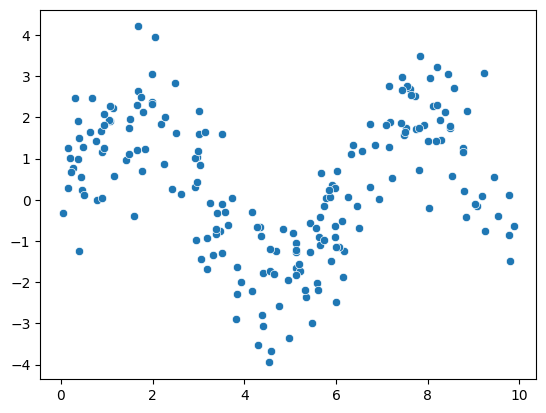

In [7]:
n = 200

sigma2_1 = 1

np.random.seed(10)
x1 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_f1 = lambda x : 2*np.sin(x)
y1 = true_f1(x1) + np.random.normal(loc = 0.0, scale = np.sqrt(sigma2_1), size = n)

sns.scatterplot(x = x1, y = y1)
plt.show()

In [8]:
regression1_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y1)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y1)}
}

def regression1_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2")
    # Simply replaces the linear predictor by the nn_output
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression1_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression1_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression1_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [9]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    data1 = [y1]
    
    sort_x1 = np.sort(x1)
    regression1_mu_before_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_before_pretrain = regression1_model.predict("sigma2")
    
    regression1_model.pre_train_model(x1, data1,
                                      epochs = 500, shuffle = True,
                                      metrics_update_freq = 50,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression1_mu_after_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_pretrain = regression1_model.predict("sigma2")

In [10]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    regression1_model.train_model(x1, data1,
                                  epochs = 15000, shuffle = True,
                                  metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                  verbose = 1, print_freq = 100)
    
    regression1_mu_after_train = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_train = regression1_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9500 / 15000 ]  | Loss:  384.853027 | Param Dist:  0.0527916253 | Independent Learning rate:  0.00015625 | Network Learning rate:  0.00015625 | Speed:  2381  it/s   Updating nn learning rate tf.Tensor(0.01, shape=(), dtype=float32)

Done.
Initializing model fine tuning (only independent parameters and last-layer)
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
Optimizing... Epoch: [ 10200 / 15000 ]  | Loss:  385.594971 | Param Dist:  0.0118749477 | Independent Learning rate:  0.0001 | Network Learning rate:  0.0001 | Speed:  2445  it/s    it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 9.621 seconds.


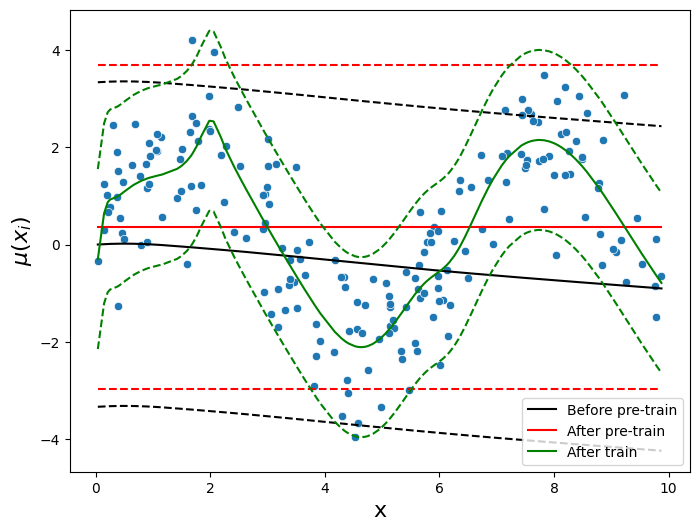

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)

sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain - 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain + 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain - 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain + 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train - 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train + 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [12]:
sort_x1 = np.sort(x1)

df_summary1 = regression1_model.summary(sort_x1[:,None])
df_summary1.insert(1, "x", sort_x1)
df_summary1

,index,x,sigma2,sigma2_se,sigma2_lower,sigma2_upper,mu,mu_se,mu_lower,mu_upper
0,1,0.039483,0.855942,0.085592,0.688185,1.023699,-0.295704,0.750834,-1.767311,1.175904
1,2,0.146349,0.855942,0.085592,0.688185,1.023699,0.630969,0.851533,-1.038006,2.299944
2,3,0.148600,0.855942,0.085592,0.688185,1.023699,0.643494,0.854230,-1.030766,2.317754
3,4,0.207519,0.855942,0.085592,0.688185,1.023699,0.863661,0.933504,-0.965973,2.693295
4,5,0.211652,0.855942,0.085592,0.688185,1.023699,0.872353,0.939595,-0.969219,2.713925
...,...,...,...,...,...,...,...,...,...,...
195,196,9.533933,0.855942,0.085592,0.688185,1.023699,-0.189112,0.416144,-1.004740,0.626515
196,197,9.770807,0.855942,0.085592,0.688185,1.023699,-0.608160,0.424358,-1.439886,0.223567
197,198,9.778993,0.855942,0.085592,0.688185,1.023699,-0.622237,0.424677,-1.454590,0.210115
198,199,9.788191,0.855942,0.085592,0.688185,1.023699,-0.638023,0.425039,-1.471085,0.195038


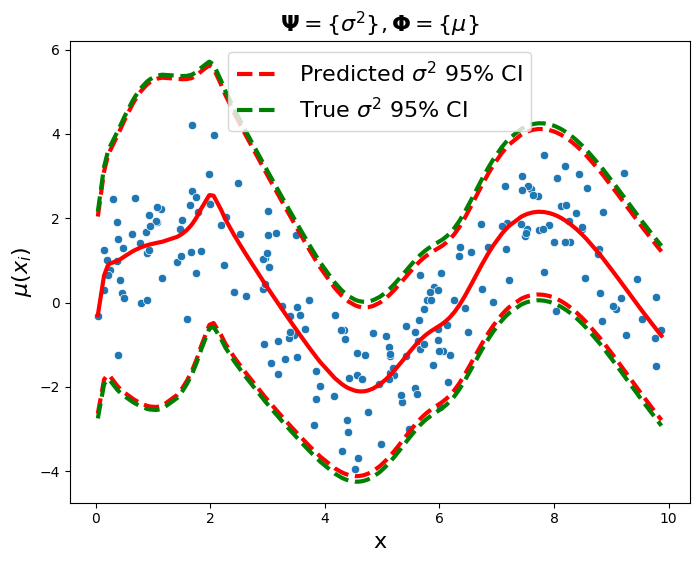

In [13]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var1 = df_summary1["mu_se"]**2 + df_summary1["sigma2"]
y_new_lower1 = df_summary1["mu"] - z_norm * np.sqrt(y_new_var1)
y_new_upper1 = df_summary1["mu"] + z_norm * np.sqrt(y_new_var1)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)
sns.lineplot(x = sort_x1, y = df_summary1["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x1, y = y_new_lower1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_1 = sigma2_1
y_new_lower1_true = df_summary1["mu"] - z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )
y_new_upper1_true = df_summary1["mu"] + z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )

# sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "purple", linestyle = "dashed", ax = ax)
# sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "purple", linestyle = "dashed", ax = ax)
sns.lineplot(x = sort_x1, y = y_new_lower1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\sigma^2\}, \boldsymbol{\Phi} = \{\mu\}$", fontsize = 16)

plt.show()

Just to exemplify the method variable_function_covariance as a general way of obtaining the covariance structure of any function of the parameters, we consider the transformation
\begin{equation*}
f(\mu, \sigma^2) = [\mu, 2\sigma^2]
\end{equation*}
Of course, we expect to see a $2 \times 2$ covariance matrix whose diagonal is equivalent to $\text{Var}[\widehat{\mu}]$ and $4\text{Var}[\widehat{\sigma}^2]$.

In [14]:
def fun(model, nn_output, data):
    X, y = data
    mu = model.get_variable("mu", nn_output)
    sigma2 = model.get_variable("sigma2")
    return tf.concat([mu, 2*tf.tile(sigma2[:,None], (tf.size(mu), 1))], axis = -1)

fun_cov = regression1_model.variable_function_covariance(fun, sort_x1[:5], data1)
fun_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[5.6375176e-01, 1.3766161e-04],
        [1.3766078e-04, 2.9303826e-02]],

       [[7.2510904e-01, 1.5568773e-04],
        [1.5568665e-04, 2.9303826e-02]],

       [[7.2970921e-01, 1.5614289e-04],
        [1.5614180e-04, 2.9303826e-02]],

       [[8.7143004e-01, 1.6917181e-04],
        [1.6917047e-04, 2.9303826e-02]],

       [[8.8283861e-01, 1.7015242e-04],
        [1.7015106e-04, 2.9303826e-02]]], dtype=float32)>

In [15]:
theta_cov = regression1_model.covariance_output(sort_x1[:5])
theta_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[7.3259566e-03, 6.8830392e-05],
        [6.8830806e-05, 5.6375176e-01]],

       [[7.3259566e-03, 7.7843324e-05],
        [7.7843863e-05, 7.2510904e-01]],

       [[7.3259566e-03, 7.8070902e-05],
        [7.8071447e-05, 7.2970921e-01]],

       [[7.3259566e-03, 8.4585234e-05],
        [8.4585903e-05, 8.7143004e-01]],

       [[7.3259566e-03, 8.5075531e-05],
        [8.5076208e-05, 8.8283861e-01]]], dtype=float32)>

In [16]:
theta_cov[:,0,0]*4

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.02930383, 0.02930383, 0.02930383, 0.02930383, 0.02930383],
      dtype=float32)>

Indeed, we can see that the variances match exactly to their expected values.

### $\phi = \{\sigma^2\}, \psi = \{\mu\}$

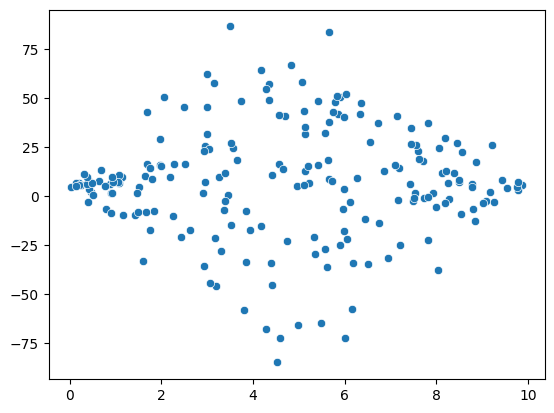

In [17]:
n = 200

mu = 5

np.random.seed(10)
x2 = np.random.uniform(low = 0.0, high = 10.0, size = n)

# true_f = lambda x : 1000 * 1/np.sqrt(2*np.pi*x) * np.exp(-(x-5)**2/(2*2))
def true_sigma2_2(x):
    y = np.zeros_like(x)
    y0 = 50
    y[x <= 5] = y0/5 * x[x <= 5]
    y[x > 5] = -y0/5 * x[x > 5] + 2*y0
    return 1+y**2

sigma2_2 = true_sigma2_2(x2)

y2 = mu + np.random.normal(loc = 0, scale = np.sqrt(sigma2_2))

sns.scatterplot(x = x2, y = y2)
plt.show()

In [18]:
regression2_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y2)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1500.0}
}

def regression2_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression2_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression2_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression2_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [19]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression2_model = thf.ModelNN(regression2_parameters, regression2_loglikelihood_loss,
                                      regression2_neural_network, regression2_network_call,
                                      regression2_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data2 = [y2]
    sort_x2 = np.sort(x2)
    
    regression2_mu_before_pretrain = regression2_model.predict("mu")
    regression2_sigma2_before_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()
    
    regression2_model.pre_train_model(x2, data2,
                                      epochs = 500, shuffle = True,
                                      metrics_update_freq = 50,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, print_freq = 50, track_time = True)
    
    regression2_mu_after_pretrain = regression2_model.predict("mu")
    regression2_sigma2_after_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

In [20]:
with tf.device("/CPU:0"):
    regression2_model.train_model(x2, data2,
                                  epochs = 15000, shuffle = True,
                                  metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  deterministic = True,
                                  verbose = 1, print_freq = 50)
    
    regression2_mu_after_train = regression2_model.predict("mu")
    regression2_sigma2_after_train = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 14950 / 15000 ]  | Loss:  1018.53479 | Param Dist:  0.000108796317 | Independent Learning rate:  9.76562478e-06 | Network Learning rate:  9.76562478e-06 | Speed:  2434  it/s   Updating nn learning rate tf.Tensor(0.01, shape=(), dtype=float32)

Done.
Initializing model fine tuning (only independent parameters and last-layer)
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
Optimizing... Epoch: [ 14950 / 15000 ]  | Loss:  1057.57959 | Param Dist:  0.000412022026 | Independent Learning rate:  9.76562478e-06 | Network Learning rate:  9.76562478e-06 | Speed:  2528  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 13.459 seconds.


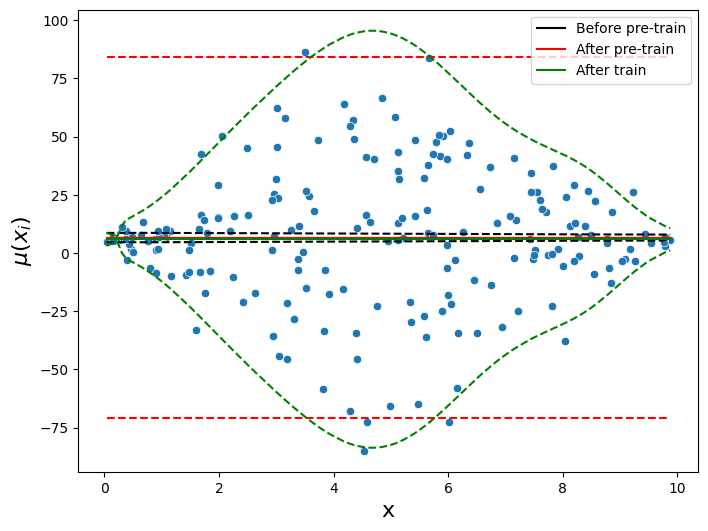

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ), ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ), ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ), ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [22]:
df_summary2 = regression2_model.summary(sort_x2[:,None])
df_summary2.insert(1, "x", sort_x2)
df_summary2

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,5.898637,0.239389,5.429443,6.367831,1.822162,1.547664,-1.211204,4.855528
1,2,0.146349,5.898637,0.239389,5.429443,6.367831,0.827882,0.880662,-0.898183,2.553947
2,3,0.148600,5.898637,0.239389,5.429443,6.367831,0.671801,0.680695,-0.662337,2.005939
3,4,0.207519,5.898637,0.239389,5.429443,6.367831,0.146062,0.127170,-0.103186,0.395310
4,5,0.211652,5.898637,0.239389,5.429443,6.367831,0.176144,0.149118,-0.116122,0.468409
...,...,...,...,...,...,...,...,...,...,...
195,196,9.533933,5.898637,0.239389,5.429443,6.367831,19.850634,8.124435,3.927032,35.774235
196,197,9.770807,5.898637,0.239389,5.429443,6.367831,8.462910,4.207313,0.216727,16.709091
197,198,9.778993,5.898637,0.239389,5.429443,6.367831,8.205585,4.105198,0.159545,16.251625
198,199,9.788191,5.898637,0.239389,5.429443,6.367831,7.924957,3.992881,0.099054,15.750860


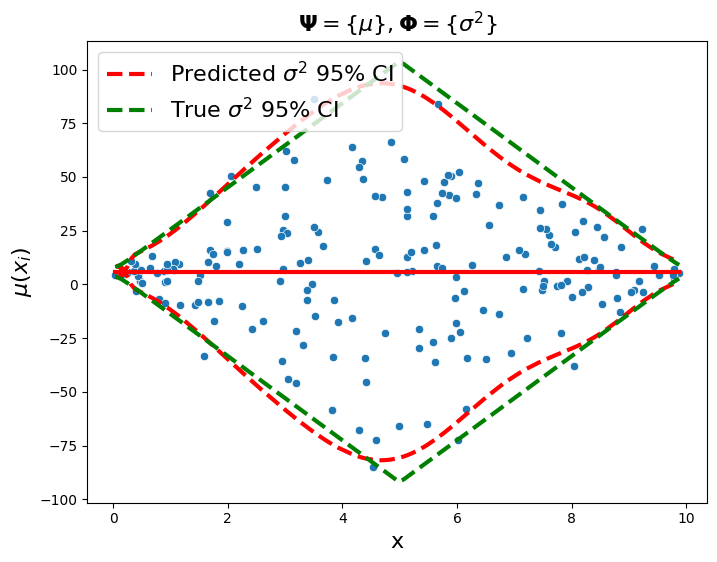

In [23]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var = df_summary2["mu_se"]**2 + df_summary2["sigma2"]
y_new_lower = df_summary2["mu"] - z_norm * np.sqrt(y_new_var)
y_new_upper = df_summary2["mu"] + z_norm * np.sqrt(y_new_var)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)
sns.lineplot(x = sort_x2, y = df_summary2["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x2, y = y_new_lower, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_2 = true_sigma2_2(sort_x2)
y_new_lower2_true = df_summary2["mu"] - z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )
y_new_upper2_true = df_summary2["mu"] + z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )

sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu\}, \boldsymbol{\Phi} = \{\sigma^2\}$", fontsize = 16)

plt.show()

### $\phi = \{\mu, \sigma^2\}, \psi = \emptyset$

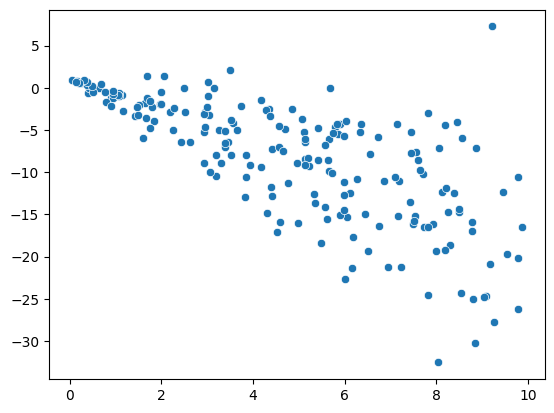

In [24]:
n = 200

np.random.seed(10)
x3 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_mu_3 = lambda x : -2*x + 1
true_sigma2_3 = lambda x : x**2

mu_3 = true_mu_3(x3)
sigma2_3 = true_sigma2_3(x3)

y3 = mu_3 + np.random.normal(loc = 0, scale = np.sqrt(sigma2_3))

sns.scatterplot(x = x3, y = y3)
plt.show()

In [25]:
regression3_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y3)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": np.var(y3)}
}

def regression3_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )

    return -loglik

def regression3_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 2, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression3_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression3_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [26]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression3_model = thf.ModelNN(regression3_parameters, regression3_loglikelihood_loss,
                                    regression3_neural_network, regression3_network_call,
                                    regression3_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data3 = [y3]
    sort_x3 = np.sort(x3)
    
    regression3_mu_before_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_before_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()
    
    regression3_model.pre_train_model(x3, data3,
                                      epochs = 500, shuffle = True,
                                      metrics_update_freq = 50,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression3_mu_after_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

In [27]:
with tf.device("/CPU:0"):
    regression3_model.train_model(x3, data3,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                  deterministic = True,
                                  verbose = 1, print_freq = 50)
    
    regression3_mu_after_train = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_train = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9550 / 15000 ]  | Loss:  7031.58 | Param Dist:  0.0284622032 | Independent Learning rate:  0.01 | Network Learning rate:  0.0001 | Speed:  2147  it/s   Updating nn learning rate tf.Tensor(0.01, shape=(), dtype=float32)

Done.
Initializing model fine tuning (only independent parameters and last-layer)
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
<Variable path=rmsprop/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
Optimizing... Epoch: [ 9950 / 15000 ]  | Loss:  7088.3623 | Param Dist:  0.000846423151 | Independent Learning rate:  0.01 | Network Learning rate:  0.0001 | Speed:  2306  it/s   /s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 10.502 seconds.


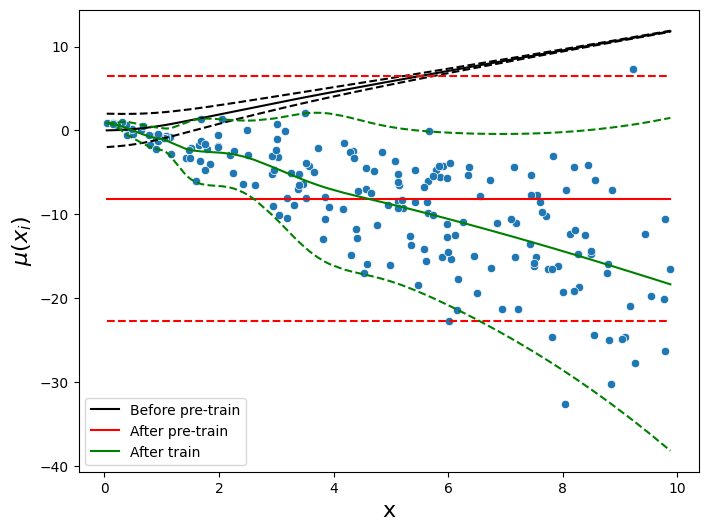

In [28]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)

sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain - 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain + 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain - 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain + 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train - 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train + 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [29]:
df_summary3 = regression3_model.summary(sort_x3[:,None])
df_summary3.insert(1, "x", sort_x3)
df_summary3

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,0.903101,0.978966,-1.015637,2.821839,0.000242,0.000343,-0.000429,0.000914
1,2,0.146349,0.781795,0.951913,-1.083921,2.647511,0.002795,0.002711,-0.002518,0.008108
2,3,0.148600,0.778307,0.951605,-1.086805,2.643420,0.002975,0.002853,-0.002617,0.008568
3,4,0.207519,0.676998,0.943899,-1.173009,2.527005,0.013835,0.010199,-0.006155,0.033825
4,5,0.211652,0.669249,0.943299,-1.179583,2.518080,0.015225,0.011073,-0.006477,0.036927
...,...,...,...,...,...,...,...,...,...,...
195,196,9.533933,-17.600588,5.076642,-27.550623,-7.650553,86.881676,402.442078,-701.890320,875.653625
196,197,9.770807,-18.112598,5.264562,-28.430950,-7.794247,94.660042,454.728973,-796.592346,985.912415
197,198,9.778993,-18.130360,5.271080,-28.461487,-7.799232,94.940987,456.644073,-800.064941,989.946899
198,199,9.788191,-18.150320,5.278406,-28.495804,-7.804835,95.257782,458.805481,-803.984497,994.500000


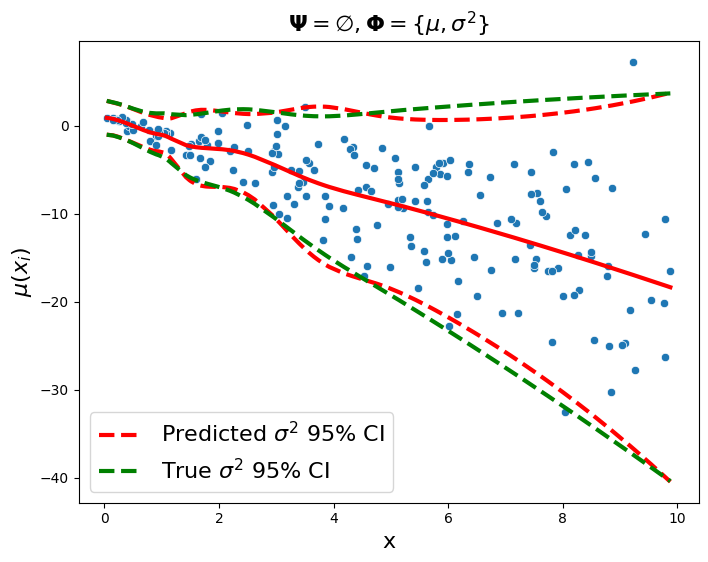

In [30]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var3 = df_summary3["mu_se"]**2 + df_summary3["sigma2"]
y_new_lower3 = df_summary3["mu"] - z_norm * np.sqrt(y_new_var3)
y_new_upper3 = df_summary3["mu"] + z_norm * np.sqrt(y_new_var3)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)
sns.lineplot(x = sort_x3, y = df_summary3["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x3, y = y_new_lower3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x3, y = y_new_upper3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_3 = true_sigma2_3(sort_x3)
y_new_lower3_true = df_summary3["mu"] - z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )
y_new_upper3_true = df_summary3["mu"] + z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )

sns.lineplot(x = sort_x3, y = y_new_lower3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x3, y = y_new_upper3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \emptyset, \boldsymbol{\Phi} = \{\mu, \sigma^2\}$", fontsize = 16)

plt.show()